# Mohit Khyalia
## 24B2289
**Course:** DS Fundamentals with Python, Learners' Space 2026  
**Phase:** Phase 1 — Python Modules

---
## Question 1

Create a 5×5 NumPy array with random integers between 1 and 100 and perform the following tasks:
- **(a)** Extract the middle element
- **(b)** Mean of each row
- **(c)** Elements greater than overall mean
- **(d)** Spiral order traversal function

In [1]:
import numpy as np

arr = np.random.randint(1, 101, size=(5, 5))
print(arr)

[[19 82 56 88 60]
 [62 17 24 76 73]
 [77 92 10 57 18]
 [47 37  2 44 99]
 [95 24 99 33 48]]


### (a) Middle Element

In [2]:
middle = arr[2, 2]
print("Middle element:", middle)

Middle element: 10


### (b) Mean of Each Row

In [3]:
row_means = np.mean(arr, axis=1)
for i, m in enumerate(row_means):
    print(f"Row {i}: {m}")

Row 0: 61.0
Row 1: 50.4
Row 2: 50.8
Row 3: 45.8
Row 4: 59.8


### (c) Elements Greater Than Overall Mean

In [4]:
overall_mean = np.mean(arr)
print("Overall mean:", overall_mean)
filtered = arr[arr > overall_mean]
print("Elements greater than mean:", filtered)

Overall mean: 53.56
Elements greater than mean: [82 56 88 60 62 76 73 77 92 57 99 95 99]


### (d) Spiral Order Function

In [5]:
def numpy_spiral_order(matrix):
    result = []
    top, bottom, left, right = 0, matrix.shape[0] - 1, 0, matrix.shape[1] - 1
    while top <= bottom and left <= right:
        for col in range(left, right + 1):
            result.append(matrix[top, col])
        top += 1
        for row in range(top, bottom + 1):
            result.append(matrix[row, right])
        right -= 1
        if top <= bottom:
            for col in range(right, left - 1, -1):
                result.append(matrix[bottom, col])
            bottom -= 1
        if left <= right:
            for row in range(bottom, top - 1, -1):
                result.append(matrix[row, left])
            left += 1
    return result

spiral = numpy_spiral_order(arr)
print("Spiral order:", spiral)

Spiral order: [np.int64(19), np.int64(82), np.int64(56), np.int64(88), np.int64(60), np.int64(73), np.int64(18), np.int64(99), np.int64(48), np.int64(33), np.int64(99), np.int64(24), np.int64(95), np.int64(47), np.int64(77), np.int64(62), np.int64(17), np.int64(24), np.int64(76), np.int64(57), np.int64(44), np.int64(2), np.int64(37), np.int64(92), np.int64(10)]


---
## Question 2

Using the **Video Game Sales** dataset to answer the following questions.

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('videogamesales.csv')
print(df.shape)
print(df.columns.tolist())
df.head()

(16583, 9)
['Name', 'Platform', 'Year', 'Genre', 'Publisher', 'NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']


,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales
0,Asteroids,2600,1980.0,Shooter,Atari,4.00,0.26,0.0,0.05
1,Missile Command,2600,1980.0,Shooter,Atari,2.56,0.17,0.0,0.03
2,Kaboom!,2600,1980.0,Misc,Activision,1.07,0.07,0.0,0.01
3,Defender,2600,1980.0,Misc,Atari,0.99,0.05,0.0,0.01
4,Boxing,2600,1980.0,Fighting,Activision,0.72,0.04,0.0,0.01


### (a) Global Sales Column — Sort by Global Sales

In [7]:
df['Global_Sales'] = df['NA_Sales'] + df['EU_Sales'] + df['JP_Sales'] + df['Other_Sales']
df_sorted = df.sort_values('Global_Sales', ascending=False).reset_index(drop=True)
print(df_sorted.head(10).to_string())

                        Name Platform    Year         Genre Publisher  NA_Sales  EU_Sales  JP_Sales  Other_Sales  Global_Sales
0                 Wii Sports      Wii  2006.0        Sports  Nintendo     41.49     29.02      3.77         8.46         82.74
1          Super Mario Bros.      NES  1985.0      Platform  Nintendo     29.08      3.58      6.81         0.77         40.24
2             Mario Kart Wii      Wii  2008.0        Racing  Nintendo     15.85     12.88      3.79         3.31         35.83
3          Wii Sports Resort      Wii  2009.0        Sports  Nintendo     15.75     11.01      3.28         2.96         33.00
4   Pokemon Red/Pokemon Blue       GB  1996.0  Role-Playing  Nintendo     11.27      8.89     10.22         1.00         31.38
5                     Tetris       GB  1989.0        Puzzle  Nintendo     23.20      2.26      4.22         0.58         30.26
6      New Super Mario Bros.       DS  2006.0      Platform  Nintendo     11.38      9.23      6.50         2.9

### (b) Total Copies Sold by Genre (Global)

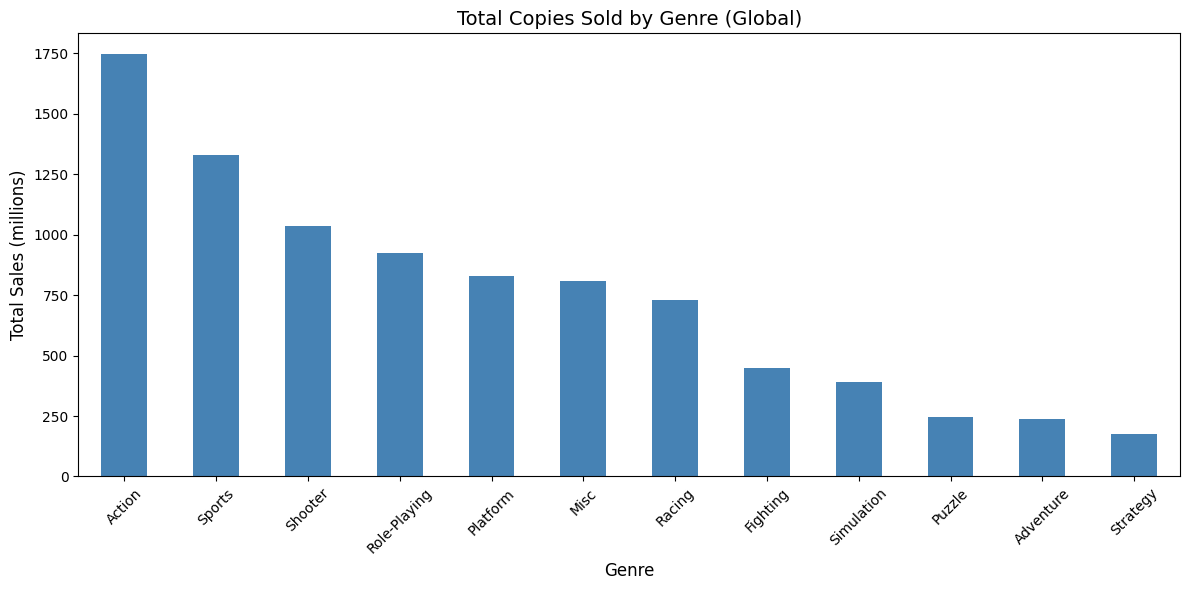

In [8]:
genre_sales = df.groupby('Genre')['Global_Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
genre_sales.plot(kind='bar', color='steelblue')
plt.title('Total Copies Sold by Genre (Global)', fontsize=14)
plt.xlabel('Genre', fontsize=12)
plt.ylabel('Total Sales (millions)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### (c) Grand Theft Auto Games — Name, Platform, Year, EU+JP Sales

In [9]:
gta = df[df['Name'].str.contains('Grand Theft Auto', na=False)].copy()
gta['EU_JP_Sales'] = (gta['EU_Sales'] + gta['JP_Sales']).round(2)
gta_df = gta[['Name', 'Platform', 'Year', 'EU_JP_Sales']].reset_index(drop=True)
print(gta_df.to_string())

                                                                             Name Platform    Year  EU_JP_Sales
0                                                                Grand Theft Auto       PS  1997.0         1.39
1                                                              Grand Theft Auto 2       PS  1998.0         2.07
2                                  Grand Theft Auto: Mission Pack #1, London 1969       PS  1998.0         0.04
3                                                            Grand Theft Auto III      PS2  2001.0         4.81
4                                                     Grand Theft Auto: Vice City      PS2  2002.0         5.96
5                                                            Grand Theft Auto III       PC  2002.0         0.01
6   Rockstar Games Double Pack: Grand Theft Auto III & Grand Theft Auto Vice City       XB  2003.0         0.56
7   Rockstar Games Double Pack: Grand Theft Auto III & Grand Theft Auto Vice City      PS2  2003.0      

### (d) GTA Total Sales by Region — Pie Chart

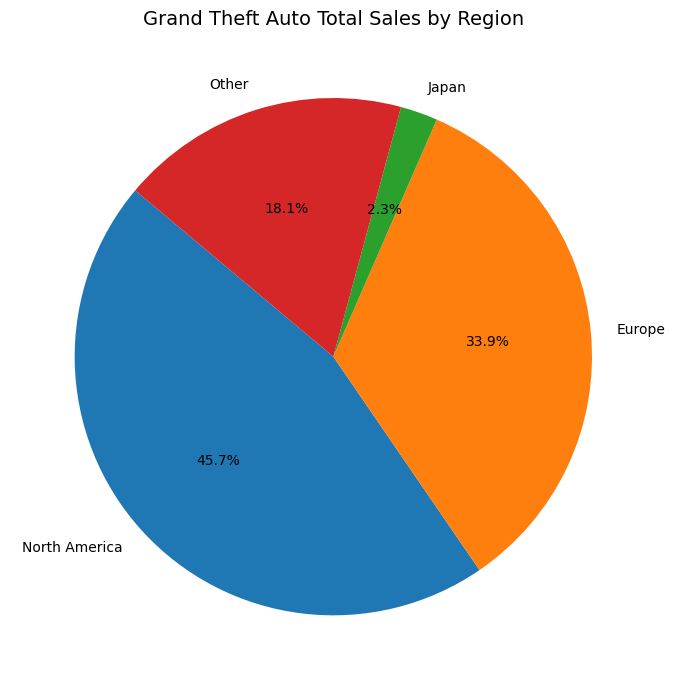

In [10]:
gta_totals = gta[['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']].sum()
labels = ['North America', 'Europe', 'Japan', 'Other']
sizes = gta_totals.values

plt.figure(figsize=(7, 7))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140)
plt.title('Grand Theft Auto Total Sales by Region', fontsize=14)
plt.tight_layout()
plt.show()